In [1]:
# import libraries
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.api import VARMAX

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [42]:
# read in data
df = pd.read_csv('../datasets/TX-Data/met-cleanedup/met_data1_cleaned.csv', sep=",", parse_dates=["Date"], index_col="Date")

In [43]:
# Slice data to isolate 2015-2020
df = df[(df.index > "2014-12-31 23:00") & (df.index < "2020-12-31 23:00")]

In [44]:
# Replace inf values and Fill nan values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.mean(), inplace=True)

In [45]:
# Reseample with monthly mean
df = df.resample('M').mean()

In [46]:
# removes spaces in the column names
def remove_spaces(df):
    df.columns = df.columns.str.replace(' ','')
    df['Ppt'] = df['Ppt'].astype(float)
    df['Tair'] = df['Tair'].astype(float)
    df['RH'] = df['RH'].astype(float)
    df['Windspeed'] = df['Windspeed'].astype(float)
    df['Winddirection'] = df['Winddirection'].astype(float)
    df['Srad'] = df['Srad'].astype(float)  

In [47]:
# remove column name spaces of each DataFrame 
remove_spaces(df)

In [48]:
drop_exog_cols = ['Ppt', 'RH', 'Windspeed', 'Winddirection']
endog = df.drop(drop_cols, axis=1)

drop_endog_cols = ['Tair', 'Srad']
exog = df.drop(drop_cols, axis=1)

In [49]:
# Verify shape of data frame
df.shape

(72, 6)

In [51]:
order = (3, 3)
VARMAX_model = VARMAX(endog, order = order)
results = VARMAX_model.fit()

In [59]:
results.summary()

Dep. Variable:,"['Tair', 'Srad']",No. Observations:,72
Model:,"VARMA(3,3)",Log Likelihood,-458.003
,+ intercept,AIC,974.006
Date:,"Mon, 14 Aug 2023",BIC,1040.030
Time:,12:58:10,HQIC,1000.290
Sample:,01-31-2015,,
,- 12-31-2020,,
Covariance Type:,opg,,
Ljung-Box (L1) (Q):,"0.15, 0.00",Jarque-Bera (JB):,"0.16, 8.93"
Prob(Q):,"0.70, 0.99",Prob(JB):,"0.92, 0.01"
Heteroskedasticity (H):,"1.53, 1.14",Skew:,"-0.10, -0.73"


In [60]:
# Forecast 12 months
forecast_steps = 12

forecast = results.forecast(steps=forecast_steps)

forecast
# Convert the forecast array to a DataFrame
forecast_df = pd.DataFrame(forecast, columns=['Tair', 'Srad'])

# Display the forecasted values
print("\nForecasted Values:")
print(forecast_df)


Forecasted Values:
                 Tair        Srad
2021-01-31  10.020539  119.799855
2021-02-28  11.810106  141.739885
2021-03-31  14.986213  189.623282
2021-04-30  19.194350  227.010241
2021-05-31  23.448173  255.061699
2021-06-30  26.233474  272.865327
2021-07-31  27.084867  269.454315
2021-08-31  25.937826  246.000754
2021-09-30  23.084744  213.363954
2021-10-31  19.298808  178.595899
2021-11-30  15.663715  149.637755
2021-12-31  13.073565  134.814016


In [61]:
total_len = len(df.Tair)
forecast_x_values = range(total_len - len(forecast_df.Tair), total_len)

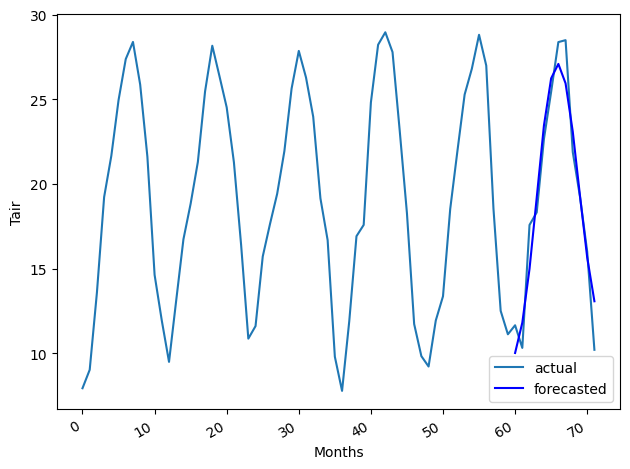

In [62]:
# Visualize predictions
fig, ax = plt.subplots()

# Plot actual data
ax.plot(df.Tair.tolist(), label='actual')

# Plot forecasted data with adjusted x-axis values
ax.plot(forecast_x_values, forecast_df.Tair, 'b-', label='forecasted')

ax.set_xlabel('Months')
ax.set_ylabel('Tair')
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()

# Show the plot
plt.show()

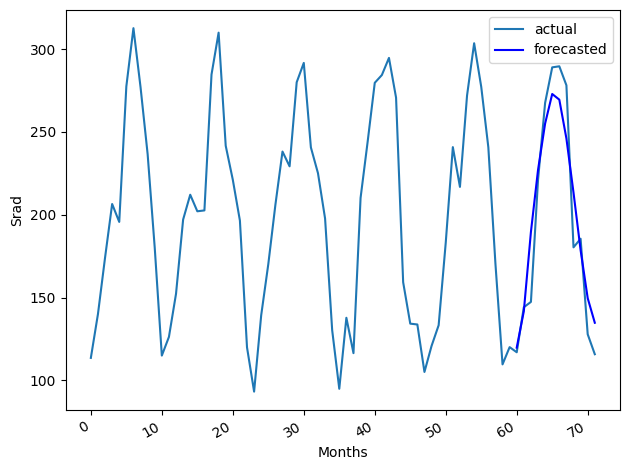

In [63]:
# Visualize predictions
fig, ax = plt.subplots()

# Plot actual data
ax.plot(df.Srad.tolist(), label='actual')

# Plot forecasted data with adjusted x-axis values
ax.plot(forecast_x_values, forecast_df.Srad, 'b-', label='forecasted')

ax.set_xlabel('Months')
ax.set_ylabel('Srad')
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()

# Show the plot
plt.show()

In [64]:
mse_srad = mean_squared_error(forecast_df.Srad,df.Srad.tolist()[60:])
mse_srad

471.6212023272755

In [65]:
mse_tair = mean_squared_error(forecast_df.Tair,df.Tair.tolist()[60:])
mse_tair

2.6324470755020766